# EDA of CAIC data

### Import Libraries

In [4]:
# notebooks/01_eda_caic_avalanches.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/processed/caic_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Total observations: {len(df):,}")
print(f"\nDataset shape: {df.shape}")

Total observations: 21,107

Dataset shape: (21107, 10)


### Missing Data Analysis

MISSING DATA ANALYSIS

Columns with missing data:
                Missing Count  Missing %
Observation ID           1997   9.461316
Type                     1687   7.992609
Trigger                   591   2.800019
Aspect                    292   1.383427
Area                       94   0.445350


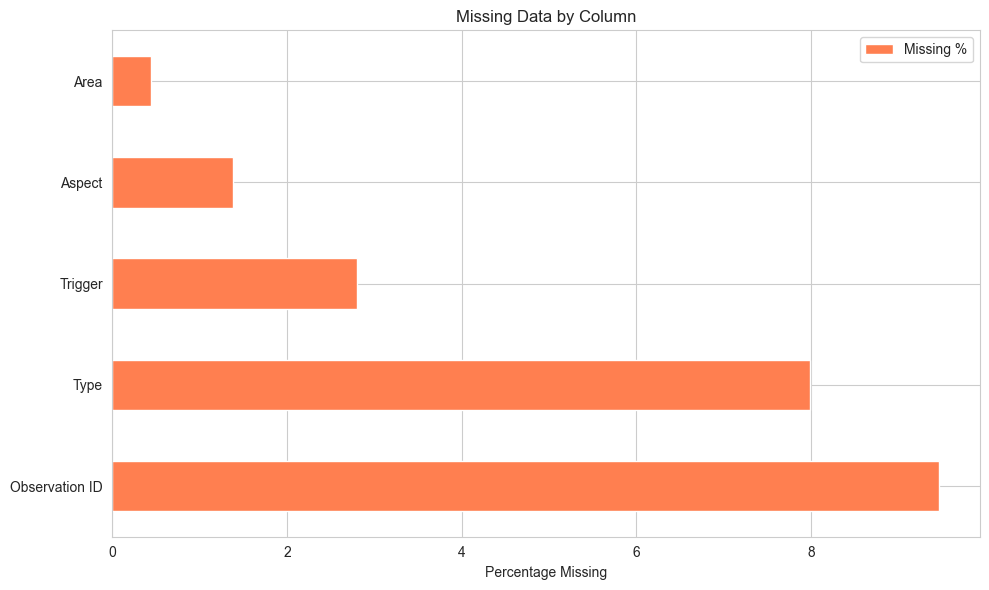


FEATURE COMPLETENESS
Aspect              : 20,815 valid ( 98.6%),    292 missing (  1.4%)
Type                : 19,420 valid ( 92.0%),  1,687 missing (  8.0%)
Trigger             : 20,516 valid ( 97.2%),    591 missing (  2.8%)
Area                : 21,013 valid ( 99.6%),     94 missing (  0.4%)
avalanche_size      : 21,107 valid (100.0%),      0 missing (  0.0%)

SAMPLE VALUES (to verify cleaning worked)

Aspect - Unique values:
Aspect
E      5660
NE     5135
SE     2904
N      2567
NW     1293
W      1205
S      1195
SW      743
U        60
All      53
Name: count, dtype: int64

Type - Unique values:
Type
SS    11755
HS     3160
WL     2051
L       991
WS      756
U       459
C       204
G        31
R        10
I         3
Name: count, dtype: int64

Trigger - Unique values:
Trigger
N     14426
AS     4189
U       835
AM      442
AR      278
AF       85
AE       65
AC       43
AK       19
AV       19
Name: count, dtype: int64


In [5]:
# Missing data overview
print("="*60)
print("MISSING DATA ANALYSIS")
print("="*60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Only show columns with missing data
if missing_df['Missing Count'].sum() > 0:
    print("\nColumns with missing data:")
    print(missing_df[missing_df['Missing Count'] > 0])
    
    # Visualize missing data
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df[missing_df['Missing Count'] > 0].plot(
        kind='barh', 
        y='Missing %', 
        ax=ax,
        color='coral'
    )
    ax.set_xlabel('Percentage Missing')
    ax.set_title('Missing Data by Column')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing data in any columns!")

# Detail for key feature columns
print("\n" + "="*60)
print("FEATURE COMPLETENESS")
print("="*60)

for col in ['Aspect', 'Type', 'Trigger', 'Area', 'avalanche_size']:
    if col in df.columns:
        missing_count = df[col].isna().sum()
        valid_count = df[col].notna().sum()
        print(f"{col:20s}: {valid_count:6,} valid ({valid_count/len(df)*100:5.1f}%), {missing_count:6,} missing ({missing_count/len(df)*100:5.1f}%)")

# Show examples of valid values for context
print("\n" + "="*60)
print("SAMPLE VALUES (to verify cleaning worked)")
print("="*60)

for col in ['Aspect', 'Type', 'Trigger']:
    if col in df.columns:
        print(f"\n{col} - Unique values:")
        print(df[col].value_counts().head(10))